# 📱 Clase 2: HealthScroller — El impacto de las redes sociales en los estudiantes

## 🚗➡📱 Problema a Solucionar

En la clase anterior estimamos **precios de coches** con un modelo de regresión. Hoy cambiamos de tema: analizamos **cómo el uso de redes sociales afecta la vida de los estudiantes** (sueño, salud mental y rendimiento académico).

El objetivo de esta clase es **doble**:

1. **Practicar análisis de datos con Pandas y Numpy** sobre el dataset `Social_media_impact_on_life.csv`.
2. **Generar un resumen de resultados** (un archivo JSON) que **alimenta a un equipo de chatbots** construido con LangGraph y un modelo local de Ollama (`gemma3:1b`).

## 🤔 Definición del Problema (Business/Científico)

**Pregunta de negocio:** ¿Más horas en redes sociales implica peor sueño, más estrés y peor nota media (GPA)?

**Tipo de tarea:** hoy no entrenamos un modelo de ML. Hacemos **análisis descriptivo, algebraico y por simulación**:

- 📊 **Estadística:** medias, medianas y comparaciones entre grupos.
- 🧮 **Álgebra:** correlaciones y recta de regresión (y = m·x + b).
- 🎲 **Simulación:** Monte Carlo, bootstrap y escenarios "¿qué pasaría si...?".

## 📊 Variable Objetivo y Características

- **Variables de interés principal:** `Academic_Performance_GPA` (nota media, 0-4) y `Mental_Health_Index`.
- **Características:** `Daily_Usage_Hours` (horas/día en redes), `Sleep_Duration_Hours`, `Perceived_Stress_Score`, `Primary_Platform`, `Gender`, `Academic_Level`, `Overall_Impact`, etc.

> 💡 Al final exportaremos `outputs/analysis_results.json`: **es el puente entre este análisis y los agentes del chatbot**.


In [1]:
# Instalaciones (en local no suelen hacer falta; en Colab descomenta la línea de abajo)
# !pip install pandas numpy matplotlib seaborn

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Pandas :", pd.__version__)
print("Numpy  :", np.__version__)
print("Seaborn:", sns.__version__)


Pandas : 2.2.2
Numpy  : 1.26.4
Seaborn: 0.13.2


## 2. Carga del Conjunto de Datos

A diferencia de la clase 1 (que corría en Colab), esta clase está pensada para correr **en local**.

Truco profesional: buscamos la **raíz del proyecto** subiendo carpetas hasta encontrar `data/`. Así el notebook funciona desde cualquier directorio.


In [2]:
# Buscamos la raíz del proyecto subiendo carpetas hasta encontrar data/
PROJECT_ROOT = Path.cwd()
for posible_raiz in [Path.cwd(), *Path.cwd().parents]:
    if (posible_raiz / "data" / "Social_media_impact_on_life.csv").exists():
        PROJECT_ROOT = posible_raiz
        break

RUTA_CSV = PROJECT_ROOT / "data" / "Social_media_impact_on_life.csv"
try:
    df = pd.read_csv(RUTA_CSV)
    print("Datos cargados exitosamente desde:", RUTA_CSV)
except FileNotFoundError:
    print("ERROR: no se encontró el CSV. Comprueba la carpeta data/")

print("Dimensiones del Dataset:", df.shape)
df.head()


Datos cargados exitosamente desde: c:\Users\Abel Perez\Desktop\Stucom\HealthScroller\data\Social_media_impact_on_life.csv
Dimensiones del Dataset: (4500, 16)


,Student_ID,Age,Gender,Academic_Level,Primary_Platform,Daily_Usage_Hours,Weekend_Extra_Hours,Device_Type,Sleep_Duration_Hours,Sleep_Quality_Score,Late_Night_Usage,Social_Comparison_Frequency,Perceived_Stress_Score,Mental_Health_Index,Academic_Performance_GPA,Overall_Impact
0,STU_2024000,19,Female,Undergraduate,Snapchat,7.5,1.5,Smartphone,5.9,2,True,Always,20.0,73,2.73,Neutral
1,STU_2024001,19,Female,Undergraduate,Instagram,4.6,1.3,Smartphone,7.9,3,True,Sometimes,17.0,90,3.21,Beneficial
2,STU_2024002,17,Female,High School,TikTok,10.9,1.7,Smartphone,5.2,1,True,Frequently,18.0,70,3.00,Neutral
3,STU_2024003,16,Female,High School,YouTube,6.0,2.3,Tablet,7.6,4,True,Sometimes,15.0,82,3.42,Beneficial
4,STU_2024004,17,Male,High School,LinkedIn,3.3,2.6,Smartphone,7.6,4,True,Never,16.0,84,3.41,Beneficial


## 3. Análisis Exploratorio de Datos (EDA)

Entendemos la estructura de los datos: tipos de variables, valores faltantes y duplicados.


In [3]:
df.info()

print("\nDimensiones del Dataset:", df.shape)
print("\nValores nulos por columna:")
print(df.isnull().sum())
print("\nFilas duplicadas:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   4500 non-null   object 
 1   Age                          4500 non-null   int64  
 2   Gender                       4500 non-null   object 
 3   Academic_Level               4500 non-null   object 
 4   Primary_Platform             4500 non-null   object 
 5   Daily_Usage_Hours            4500 non-null   float64
 6   Weekend_Extra_Hours          4500 non-null   float64
 7   Device_Type                  4500 non-null   object 
 8   Sleep_Duration_Hours         4500 non-null   float64
 9   Sleep_Quality_Score          4500 non-null   int64  
 10  Late_Night_Usage             4500 non-null   bool   
 11  Social_Comparison_Frequency  4500 non-null   object 
 12  Perceived_Stress_Score       4454 non-null   float64
 13  Mental_Health_Inde

### 3.1. Limpieza de Valores Faltantes

Hay nulos en `Perceived_Stress_Score` (46) y en `Academic_Performance_GPA` (85).

Igual que hicimos en la clase 1, **imputamos con la mediana**: es más robusta que la media frente a valores extremos. Después verificamos que no queda ningún nulo en el dataset.


In [4]:
columnas_con_nulos = ["Perceived_Stress_Score", "Academic_Performance_GPA"]

for columna in columnas_con_nulos:
    mediana = df[columna].median()
    df[columna] = df[columna].fillna(mediana)
    print(f"{columna}: {df[columna].isnull().sum()} nulos imputados con la mediana = {mediana:.2f}")

print("\n¿Queda algún nulo en el dataset?:", df.isnull().sum().sum())


Perceived_Stress_Score: 0 nulos imputados con la mediana = 13.00
Academic_Performance_GPA: 0 nulos imputados con la mediana = 3.46

¿Queda algún nulo en el dataset?: 0


## 3.2. Visualización de las Variables Numéricas

Como en la clase 1, visualizamos distribuciones. Fíjate en `Daily_Usage_Hours` (horas al día en redes) y `Academic_Performance_GPA` (nota media).


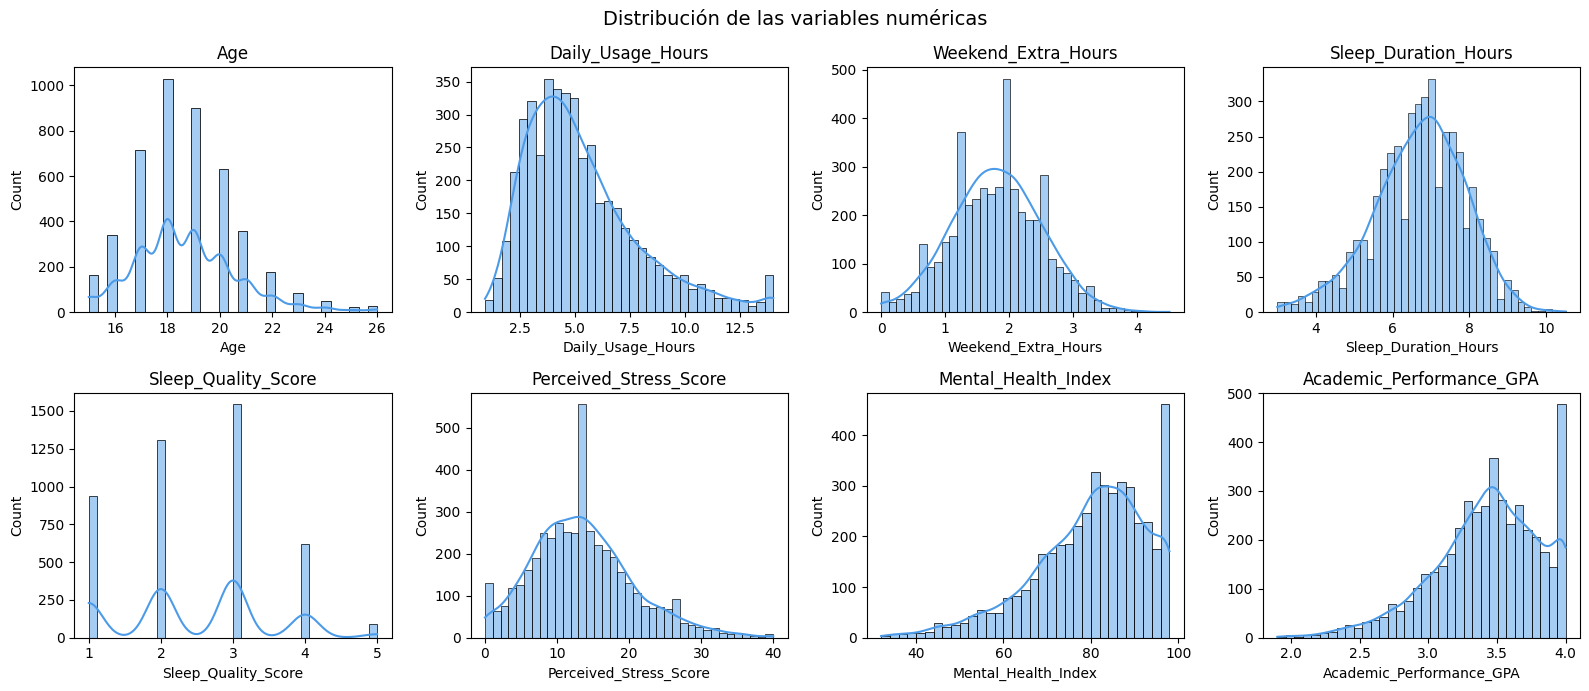

In [5]:
columnas_numericas = [
    "Age",
    "Daily_Usage_Hours",
    "Weekend_Extra_Hours",
    "Sleep_Duration_Hours",
    "Sleep_Quality_Score",
    "Perceived_Stress_Score",
    "Mental_Health_Index",
    "Academic_Performance_GPA",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, columna in zip(axes.flat, columnas_numericas):
    sns.histplot(df[columna], kde=True, ax=ax, color="#4C9BE8")
    ax.set_title(columna)
plt.suptitle("Distribución de las variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()


## 3.3. Análisis de las Variables Categóricas

¿Qué plataformas, dispositivos y niveles de estudio dominan el dataset?


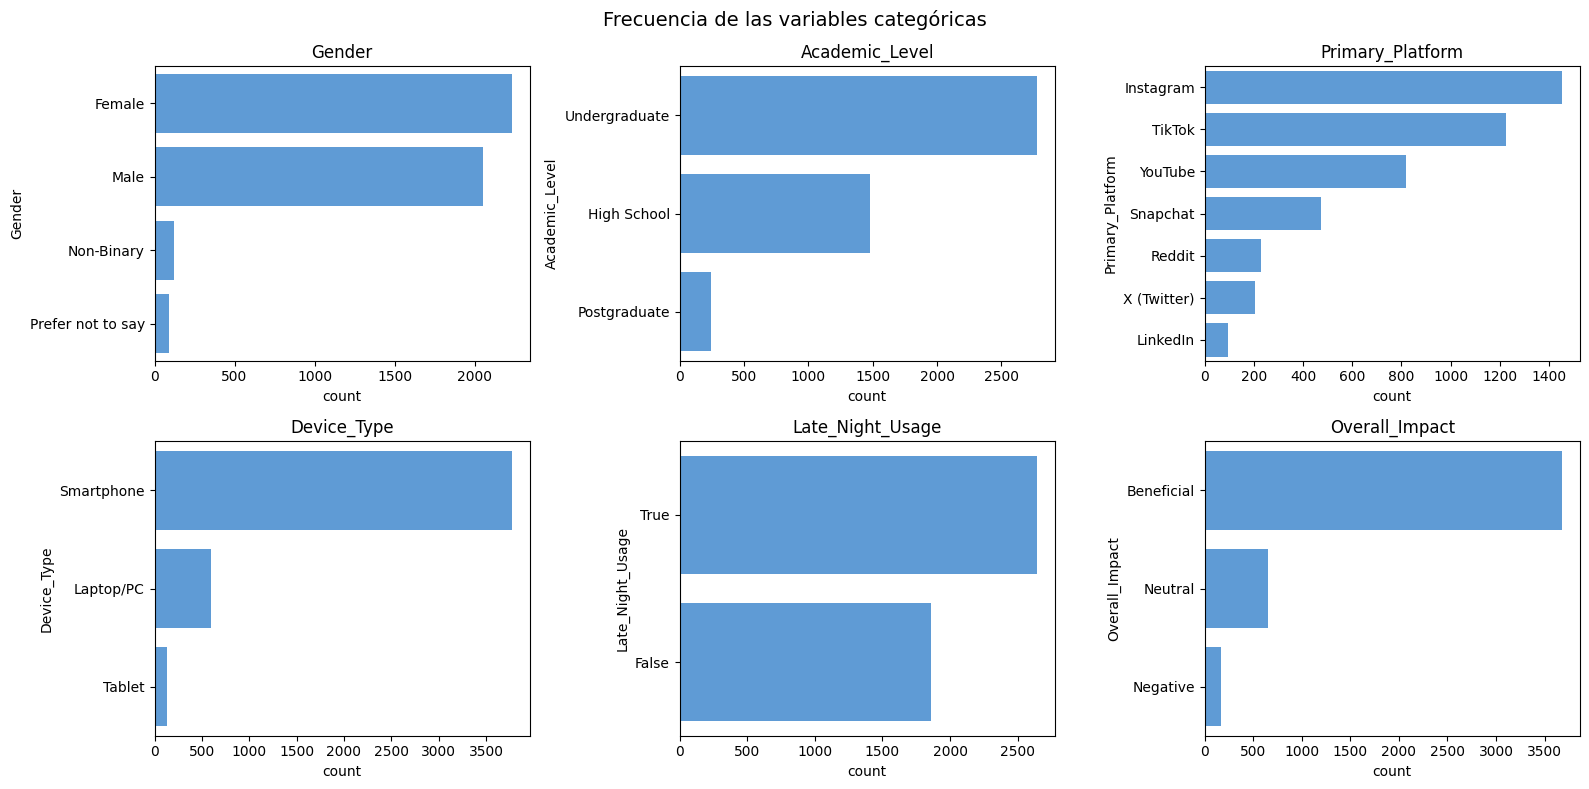

In [6]:
columnas_categoricas = [
    "Gender",
    "Academic_Level",
    "Primary_Platform",
    "Device_Type",
    "Late_Night_Usage",
    "Overall_Impact",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, columna in zip(axes.flat, columnas_categoricas):
    orden = df[columna].value_counts().index
    sns.countplot(data=df, y=columna, order=orden, ax=ax, color="#4C9BE8")
    ax.set_title(columna)
plt.suptitle("Frecuencia de las variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()


## 3.4. Métricas Clave según el Impacto Declarado

Comparamos con **boxplots** las métricas de los estudiantes según `Overall_Impact` (Beneficial / Neutral / Negative). ¿Ves diferencias en las cajas?


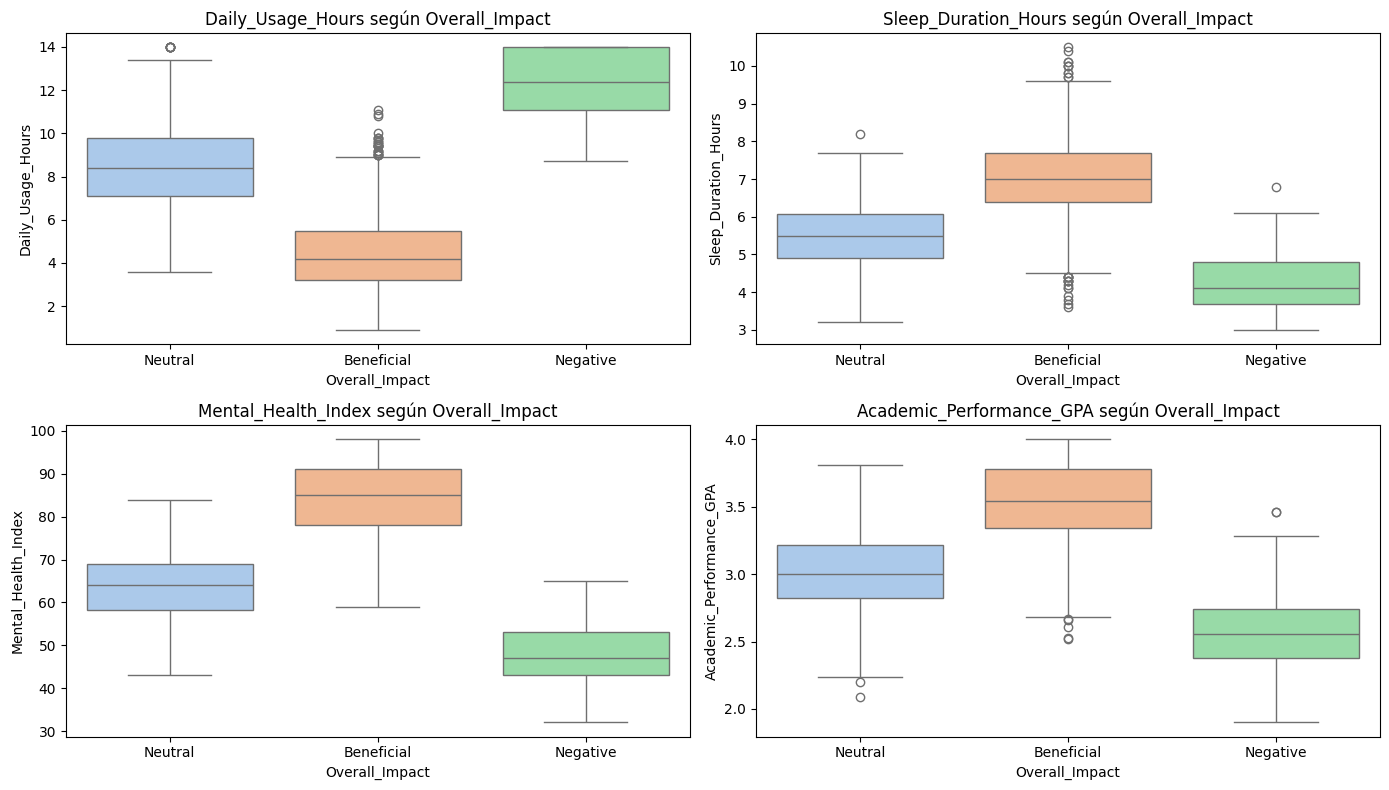

In [7]:
metricas = [
    "Daily_Usage_Hours",
    "Sleep_Duration_Hours",
    "Mental_Health_Index",
    "Academic_Performance_GPA",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, columna in zip(axes.flat, metricas):
    sns.boxplot(data=df, x="Overall_Impact", y=columna, hue="Overall_Impact", ax=ax, palette="pastel", legend=False)
    ax.set_title(f"{columna} según Overall_Impact")
plt.tight_layout()
plt.show()


## 3.5. Correlación entre Variables Numéricas

El mapa de calor nos adelanta qué pares de variables tienen relación (para el **Chatbot Algebraico**).


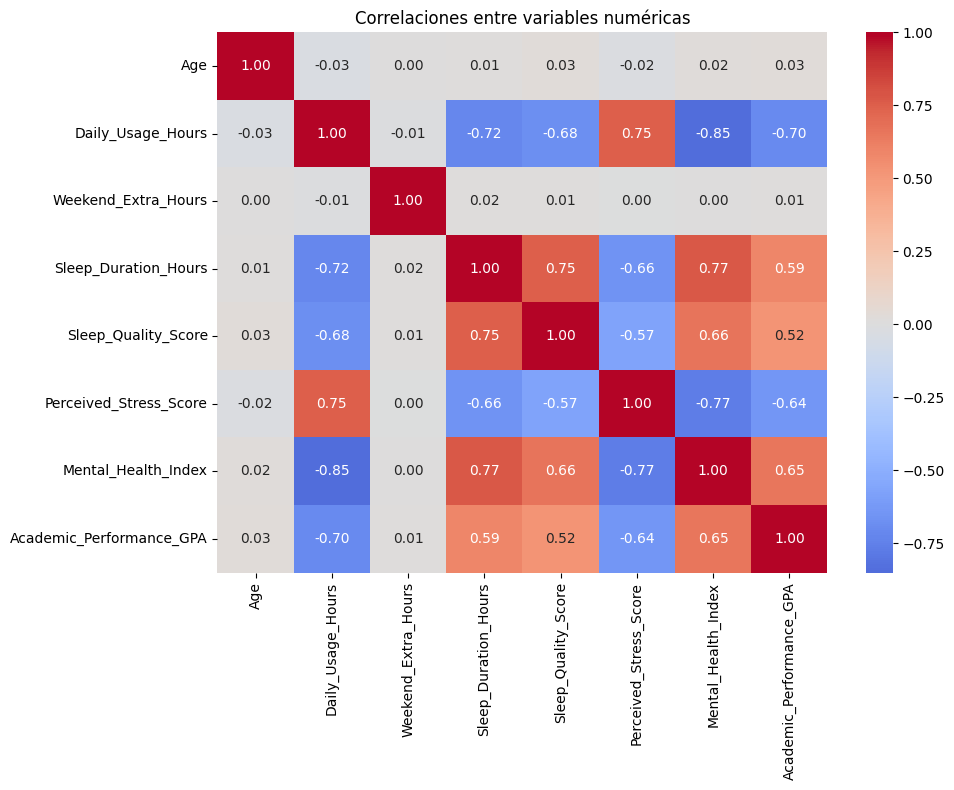

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[columnas_numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()


## 4. Estadística Descriptiva (alimenta al Chatbot Estadístico) 📊

Esta sección produce los números que luego usará el **Chatbot Estadístico**:

- Resumen general de las variables numéricas (`describe`).
- Medias por grupos: género, nivel académico, plataforma y dispositivo (`groupby`).
- Conteos de las categorías clave (`value_counts`).

Guardamos todo en el diccionario `resumen_estadistica`.


In [9]:
resumen_estadistica = {}

# 4.1. Resumen general de las numéricas (como df.describe())
resumen_estadistica["describe_numericas"] = df[columnas_numericas].describe().round(2).to_dict()

# 4.2. Medias por grupos (groupby)
resumen_estadistica["gpa_por_genero"] = df.groupby("Gender")["Academic_Performance_GPA"].mean().round(2).to_dict()
resumen_estadistica["gpa_por_nivel"] = df.groupby("Academic_Level")["Academic_Performance_GPA"].mean().round(2).to_dict()
resumen_estadistica["horas_por_plataforma"] = df.groupby("Primary_Platform")["Daily_Usage_Hours"].mean().round(2).to_dict()
resumen_estadistica["sueno_por_dispositivo"] = df.groupby("Device_Type")["Sleep_Duration_Hours"].mean().round(2).to_dict()

# 4.3. Conteos clave
resumen_estadistica["conteo_impact"] = df["Overall_Impact"].value_counts().to_dict()
resumen_estadistica["conteo_plataformas"] = df["Primary_Platform"].value_counts().to_dict()

print(json.dumps(resumen_estadistica, indent=2, ensure_ascii=False))


{
  "describe_numericas": {
    "Age": {
      "count": 4500.0,
      "mean": 18.7,
      "std": 1.98,
      "min": 15.0,
      "25%": 17.0,
      "50%": 19.0,
      "75%": 20.0,
      "max": 26.0
    },
    "Daily_Usage_Hours": {
      "count": 4500.0,
      "mean": 5.3,
      "std": 2.6,
      "min": 0.9,
      "25%": 3.4,
      "50%": 4.7,
      "75%": 6.6,
      "max": 14.0
    },
    "Weekend_Extra_Hours": {
      "count": 4500.0,
      "mean": 1.8,
      "std": 0.7,
      "min": 0.0,
      "25%": 1.3,
      "50%": 1.8,
      "75%": 2.3,
      "max": 4.5
    },
    "Sleep_Duration_Hours": {
      "count": 4500.0,
      "mean": 6.7,
      "std": 1.19,
      "min": 3.0,
      "25%": 6.0,
      "50%": 6.8,
      "75%": 7.5,
      "max": 10.5
    },
    "Sleep_Quality_Score": {
      "count": 4500.0,
      "mean": 2.47,
      "std": 1.03,
      "min": 1.0,
      "25%": 2.0,
      "50%": 3.0,
      "75%": 3.0,
      "max": 5.0
    },
    "Perceived_Stress_Score": {
      "count": 4500.

## 5. Correlaciones y Regresión (alimenta al Chatbot Algebraico) 🧮

El **Chatbot Algebraico** responderá preguntas tipo *"¿qué correlación hay entre X e Y?"* o *"¿cuánto GPA predice 7 horas de uso?"*.

Aquí calculamos:

1. **Correlaciones de Pearson** entre pares de interés con `df.corr()`.
2. **La recta de regresión** GPA ~ horas de uso con `np.polyfit`: y = m·x + b.


In [10]:
resumen_algebra = {}

# 5.1. Correlaciones de Pearson entre pares de interés
pares_de_interes = [
    ("Daily_Usage_Hours", "Academic_Performance_GPA"),
    ("Daily_Usage_Hours", "Sleep_Duration_Hours"),
    ("Daily_Usage_Hours", "Mental_Health_Index"),
    ("Daily_Usage_Hours", "Perceived_Stress_Score"),
    ("Sleep_Duration_Hours", "Academic_Performance_GPA"),
    ("Perceived_Stress_Score", "Mental_Health_Index"),
]
resumen_algebra["correlaciones"] = {
    f"{a} vs {b}": round(float(df[a].corr(df[b])), 3) for a, b in pares_de_interes
}

# 5.2. Recta de regresión: GPA en función de las horas de uso
x_reg = df["Daily_Usage_Hours"].to_numpy()
y_reg = df["Academic_Performance_GPA"].to_numpy()
pendiente, interseccion = np.polyfit(x_reg, y_reg, 1)
y_pred = pendiente * x_reg + interseccion
r2 = 1 - ((y_reg - y_pred) ** 2).sum() / ((y_reg - y_reg.mean()) ** 2).sum()

resumen_algebra["regresion_gpa_horas"] = {
    "pendiente": round(float(pendiente), 4),
    "interseccion": round(float(interseccion), 4),
    "r2": round(float(r2), 4),
    "ecuacion": f"GPA = {pendiente:.4f} * horas + {interseccion:.4f}",
}

print(json.dumps(resumen_algebra, indent=2, ensure_ascii=False))


{
  "correlaciones": {
    "Daily_Usage_Hours vs Academic_Performance_GPA": -0.704,
    "Daily_Usage_Hours vs Sleep_Duration_Hours": -0.716,
    "Daily_Usage_Hours vs Mental_Health_Index": -0.85,
    "Daily_Usage_Hours vs Perceived_Stress_Score": 0.751,
    "Sleep_Duration_Hours vs Academic_Performance_GPA": 0.589,
    "Perceived_Stress_Score vs Mental_Health_Index": -0.77
  },
  "regresion_gpa_horas": {
    "pendiente": -0.1052,
    "interseccion": 3.987,
    "r2": 0.4961,
    "ecuacion": "GPA = -0.1052 * horas + 3.9870"
  }
}


### 5.3. Visualización de la Recta de Regresión

Dibujamos la nube de puntos y la recta ajustada. Observa: la relación es **muy débil** (puntos muy dispersos), y eso también es un hallazgo importante.


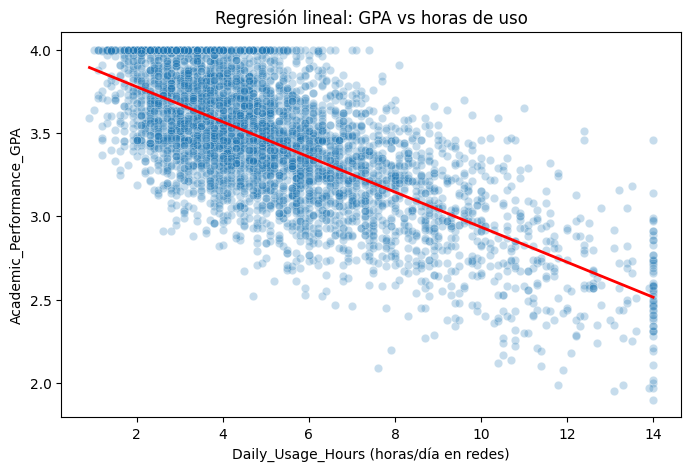

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=x_reg, y=y_reg, alpha=0.25)
x_linea = np.linspace(x_reg.min(), x_reg.max(), 100)
plt.plot(x_linea, pendiente * x_linea + interseccion, color="red", linewidth=2)
plt.xlabel("Daily_Usage_Hours (horas/día en redes)")
plt.ylabel("Academic_Performance_GPA")
plt.title("Regresión lineal: GPA vs horas de uso")
plt.show()


## 6. Simulación (alimenta al Chatbot de Simulación) 🎲

Simulamos con `numpy` usando una **semilla fija** (`default_rng(42)`) para que los resultados sean reproducibles:

1. **Monte Carlo:** si tomáramos miles de muestras de estudiantes, ¿cómo variaría la media del GPA?
2. **Bootstrap:** intervalo de confianza del 95% para la media del GPA.
3. **Escenario what-if:** ¿qué pasaría con el GPA si reducimos el uso de 7 a 3 horas?


In [12]:
rng = np.random.default_rng(42)
resumen_simulacion = {}

# 6.1. Monte Carlo: muchas muestras aleatorias y la distribución de sus medias
gpa = df["Academic_Performance_GPA"].to_numpy()
tamano_muestra, n_simulaciones = 500, 1000
medias_mc = np.array([rng.choice(gpa, size=tamano_muestra).mean() for _ in range(n_simulaciones)])
resumen_simulacion["monte_carlo_gpa"] = {
    "n_simulaciones": n_simulaciones,
    "tamano_muestra": tamano_muestra,
    "media_de_las_medias": round(float(medias_mc.mean()), 3),
    "desviacion_de_las_medias": round(float(medias_mc.std()), 3),
}

# 6.2. Bootstrap: intervalo de confianza del 95% para la media del GPA
n_repeticiones = 2000
medias_boot = np.array([rng.choice(gpa, size=gpa.size, replace=True).mean() for _ in range(n_repeticiones)])
ic_inferior, ic_superior = np.percentile(medias_boot, [2.5, 97.5])
resumen_simulacion["bootstrap_gpa_95"] = {
    "ic_inferior": round(float(ic_inferior), 3),
    "ic_superior": round(float(ic_superior), 3),
}

# 6.3. Escenario what-if con la recta de regresión
horas_actual, horas_nueva = 7.0, 3.0
gpa_actual = pendiente * horas_actual + interseccion
gpa_nuevo = pendiente * horas_nueva + interseccion
resumen_simulacion["what_if_reducir_horas"] = {
    "escenario": f"Reducir Daily_Usage_Hours de {horas_actual}h a {horas_nueva}h",
    "gpa_estimado_actual": round(float(gpa_actual), 3),
    "gpa_estimado_nuevo": round(float(gpa_nuevo), 3),
    "cambio_estimado": round(float(gpa_nuevo - gpa_actual), 3),
}

print(json.dumps(resumen_simulacion, indent=2, ensure_ascii=False))


{
  "monte_carlo_gpa": {
    "n_simulaciones": 1000,
    "tamano_muestra": 500,
    "media_de_las_medias": 3.429,
    "desviacion_de_las_medias": 0.018
  },
  "bootstrap_gpa_95": {
    "ic_inferior": 3.418,
    "ic_superior": 3.441
  },
  "what_if_reducir_horas": {
    "escenario": "Reducir Daily_Usage_Hours de 7.0h a 3.0h",
    "gpa_estimado_actual": 3.251,
    "gpa_estimado_nuevo": 3.671,
    "cambio_estimado": 0.421
  }
}


## 7. Exportación: el puente hacia los agentes 🎯

Guardamos todos los resultados en `outputs/analysis_results.json`.

El chatbot (`src/health_scroller`) leerá este archivo y lo usará de dos formas:

1. Como **briefing** dentro de los *prompts* de los agentes.
2. Como referencia para que sus **herramientas** consulten el CSV en vivo con pandas.


In [13]:
analysis_results = {
    "meta": {
        "proyecto": "HealthScroller",
        "dataset": "Social_media_impact_on_life.csv",
        "filas": int(df.shape[0]),
        "columnas": int(df.shape[1]),
        "nota": "Resumen generado por el notebook de la clase 2; alimenta a los agentes del chatbot.",
    },
    "estadistica": resumen_estadistica,
    "algebra": resumen_algebra,
    "simulacion": resumen_simulacion,
}

RUTA_JSON = PROJECT_ROOT / "outputs" / "analysis_results.json"
RUTA_JSON.parent.mkdir(parents=True, exist_ok=True)
with RUTA_JSON.open("w", encoding="utf-8") as f:
    json.dump(analysis_results, f, ensure_ascii=False, indent=2, default=float)

print("Resumen guardado en:", RUTA_JSON)
print("Secciones:", list(analysis_results.keys()))


Resumen guardado en: c:\Users\Abel Perez\Desktop\Stucom\HealthScroller\outputs\analysis_results.json
Secciones: ['meta', 'estadistica', 'algebra', 'simulacion']


## 8. Probar el Chatbot 🤖

Con el JSON ya generado, abre una **terminal** en la raíz del proyecto y ejecuta:

```bash
# 1. Arranca Ollama (si no está ya arrancado)
ollama serve

# 2. Descarga el modelo (solo la primera vez)
ollama pull gemma3:1b

# 3. Arranca el chatbot
python -m health_scroller.cli
```

Prueba preguntas como:

| Pregunta | Agente que responde |
|---|---|
| "¿Cuál es la media del GPA por género?" | **estadístico** |
| "¿Qué correlación hay entre horas de uso y sueño?" | **algebraico** |
| "¿Qué pasaría si reduzco el uso a 3 horas?" | **simulación** |
| "Hola, ¿quién eres?" | **conversación** |

También puedes forzar un agente con `/agente estadistico`, `/agente algebraico`, `/agente simulacion` o `/agente conversacion`.
